In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the data
df = pd.read_csv('all_probes_03102026.csv')

# Display basic info and first few rows to verify structure
print("Data Overview:")
print(df.info())
print("\nFirst 10 rows:")
print(df.head(10))

# Get summary stats for numerical columns
print("\nDescriptive Statistics:")
print(df.describe())

# Check for unique probes and metadata
print("\nUnique Probes:", df['Probe_ID'].unique())
print("Unique Geometries:", df['Tip_Geometry'].unique())
print("Unique Trace Widths:", df['Trace_Width_um'].unique())

Data Overview:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 96 entries, 0 to 95
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Probe_Chan      96 non-null     int64  
 1   Intan_Chan      96 non-null     int64  
 2   Mag_Ohms        96 non-null     float64
 3   Phase_deg       96 non-null     int64  
 4   Mag_MOhms       96 non-null     float64
 5   Probe_ID        96 non-null     object 
 6   Array_Shape     96 non-null     object 
 7   Trace_Width_um  96 non-null     int64  
 8   Tip_Geometry    96 non-null     object 
 9   Note            48 non-null     object 
dtypes: float64(2), int64(4), object(4)
memory usage: 7.6+ KB
None

First 10 rows:
   Probe_Chan  Intan_Chan    Mag_Ohms  Phase_deg  Mag_MOhms Probe_ID  \
0           0           3   1970000.0        -84       1.97  Probe_0   
1           1           2   1970000.0        -82       1.97  Probe_0   
2           2           1   2030000.0      


Summary of 'Healthy' Electrodes (excluding broken/outliers):
  Probe_ID Tip_Geometry Mag_MOhms                  Phase_deg           
                             mean       std count       mean        std
0  Probe_1        Point  3.758667  1.513482    15 -73.733333  12.736150
1  Probe_2         Flat  4.780000  2.560395     9 -72.000000  10.000000
2  Probe_3         Flat  4.233333  4.873667     3 -78.666667  25.794056
3  Probe_5        Point  3.091667  1.131148     6 -76.166667   7.359801

Probes ranked by consistency (lowest std dev of Magnitude):
Probe_ID
Probe_5    1.131148
Probe_1    1.513482
Probe_2    2.560395
Probe_3    4.873667
Name: Mag_MOhms, dtype: float64

Breakdown of 'Notes':
half broken                 16
heat damage at neck/PCB     16
PCB bonding row off by 1    16
Name: Note, dtype: int64


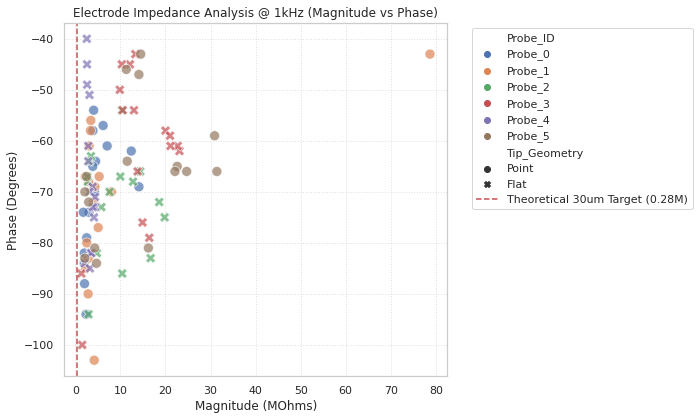

In [122]:
# Define a cutoff for "Broken" based on Mag_MOhms (e.g., > 20 MOhm is typically considered open/broken in this context)
# Or use the 'Note' column
df['Is_Broken'] = df['Note'].str.contains('broken|off', case=False, na=False) | (df['Mag_MOhms'] > 10.0)

# 1. Visualization: Phase vs Magnitude
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='Mag_MOhms', y='Phase_deg', hue='Probe_ID', style='Tip_Geometry', s=100, alpha=0.7)
plt.axvline(0.286, color='r', linestyle='--', label='Theoretical 30um Target (0.28M)')
plt.title('Electrode Impedance Analysis @ 1kHz (Magnitude vs Phase)')
plt.xlabel('Magnitude (MOhms)')
plt.ylabel('Phase (Degrees)')
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig('impedance_quadrants.png')

# 2. Comparison Table by Probe and Geometry
summary = df[~df['Is_Broken']].groupby(['Probe_ID', 'Tip_Geometry']).agg({
    'Mag_MOhms': ['mean', 'std', 'count'],
    'Phase_deg': ['mean', 'std']
}).reset_index()

print("\nSummary of 'Healthy' Electrodes (excluding broken/outliers):")
print(summary)

# 3. Identify the most reliable probe
ranking = df[~df['Is_Broken']].groupby('Probe_ID')['Mag_MOhms'].std().sort_values()
print("\nProbes ranked by consistency (lowest std dev of Magnitude):")
print(ranking)

# 4. Check Note categories
print("\nBreakdown of 'Notes':")
print(df['Note'].value_counts())

Shank Statistics for 4x4 Arrays:
                Shank       mean        std  median  count
0    Shank 1 (Ch 0-3)   4.300833   3.845603   3.310     12
1    Shank 2 (Ch 4-7)   9.355000   9.571770   4.360     12
2   Shank 3 (Ch 8-11)  15.725833  22.050192   4.820     12
3  Shank 4 (Ch 12-15)   4.399167   3.945650   2.825     12


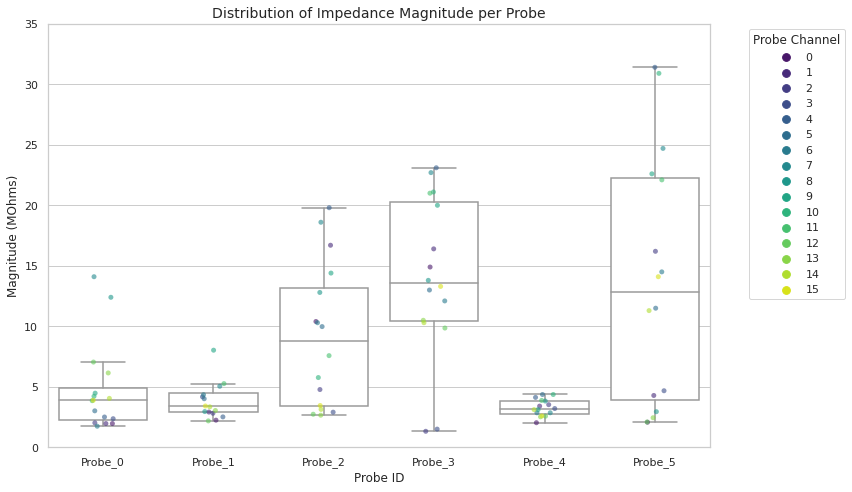

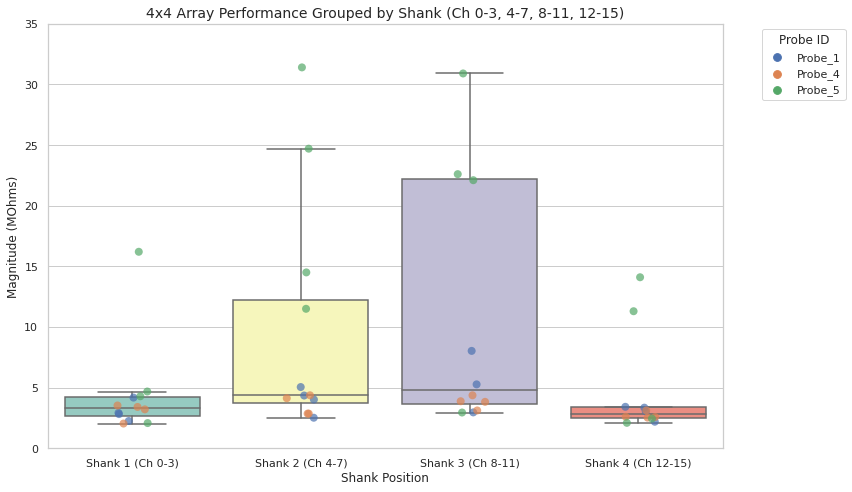

In [121]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np


## Limiting the Y-Lim view


# Load the data
df = pd.read_csv('all_probes_03102026.csv')

# 1. Define Shank grouping for 4x4 arrays
def get_shank(chan):
    if 0 <= chan <= 3: return 'Shank 1 (Ch 0-3)'
    elif 4 <= chan <= 7: return 'Shank 2 (Ch 4-7)'
    elif 8 <= chan <= 11: return 'Shank 3 (Ch 8-11)'
    elif 12 <= chan <= 15: return 'Shank 4 (Ch 12-15)'
    return 'Other'

df['Shank'] = df['Probe_Chan'].apply(get_shank)

# Set aesthetic style
sns.set_theme(style="whitegrid")

# Create Plot 1: All Probes (Boxplot + StripPlot Overlay)
plt.figure(figsize=(12, 7))
sns.boxplot(data=df, x='Probe_ID', y='Mag_MOhms', color='white', showfliers=False)
sns.stripplot(data=df, x='Probe_ID', y='Mag_MOhms', hue='Probe_Chan', palette='viridis', alpha=0.6, jitter=True)
# plt.yscale('log')
plt.title('Distribution of Impedance Magnitude per Probe', fontsize=14)
# plt.ylabel('Magnitude (MOhms) - Log Scale', fontsize=12)
plt.ylabel('Magnitude (MOhms)', fontsize=12)
plt.ylim([0,35])
plt.xlabel('Probe ID', fontsize=12)
plt.legend(title='Probe Channel', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig('all_probes_distribution.png')

# Create Plot 2: 4x4 Arrays only, grouped by Shank
df_4x4 = df[df['Array_Shape'] == '4x4'].copy()

plt.figure(figsize=(12, 7))
sns.boxplot(data=df_4x4, x='Shank', y='Mag_MOhms', palette='Set3', showfliers=False)
sns.stripplot(data=df_4x4, x='Shank', y='Mag_MOhms', hue='Probe_ID', palette='deep', alpha=0.7, jitter=True, s=8)
# plt.yscale('log')
plt.title('4x4 Array Performance Grouped by Shank (Ch 0-3, 4-7, 8-11, 12-15)', fontsize=14)
# plt.ylabel('Magnitude (MOhms) - Log Scale', fontsize=12)
plt.ylabel('Magnitude (MOhms)', fontsize=12)
plt.ylim([0,35])
plt.xlabel('Shank Position', fontsize=12)
plt.legend(title='Probe ID', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig('4x4_shank_analysis.png')

# Statistical Summary for Shanks in 4x4
shank_stats = df_4x4.groupby('Shank')['Mag_MOhms'].agg(['mean', 'std', 'median', 'count']).reset_index()
print("Shank Statistics for 4x4 Arrays:")
print(shank_stats)

# Save the updated dataframe with Shank info
# df.to_csv('probes_analysis_with_shanks.csv', index=False)

Shank Statistics for 4x4 Arrays:
                Shank      mean       std  median  count
0    Shank 1 (Ch 0-3)  3.219091  0.906272   3.210     11
1    Shank 2 (Ch 4-7)  3.770000  0.905980   4.075      8
2   Shank 3 (Ch 8-11)  4.301250  1.701532   3.855      8
3  Shank 4 (Ch 12-15)  2.739000  0.466725   2.590     10


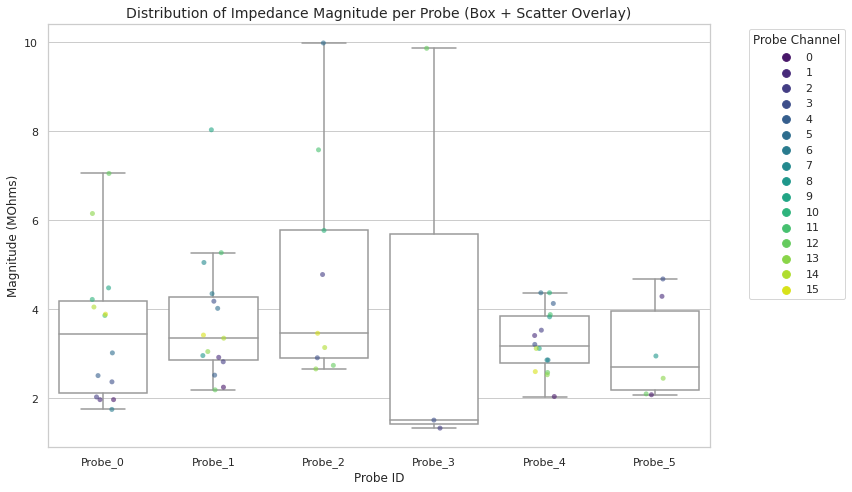

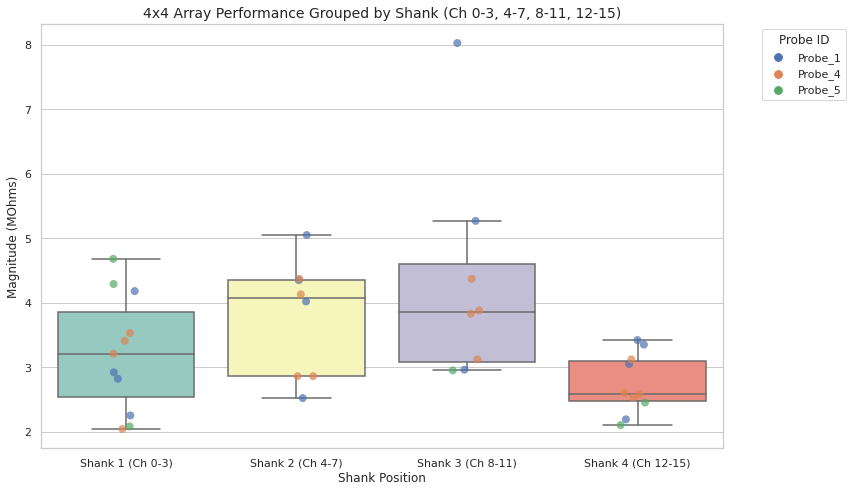

In [119]:

## Limiting the data in Y-Axis
# df['Mag_MOhms'] < 20]

# Load the data
df = pd.read_csv('all_probes_03102026.csv')

# 1. Define Shank grouping for 4x4 arrays
def get_shank(chan):
    if 0 <= chan <= 3: return 'Shank 1 (Ch 0-3)'
    elif 4 <= chan <= 7: return 'Shank 2 (Ch 4-7)'
    elif 8 <= chan <= 11: return 'Shank 3 (Ch 8-11)'
    elif 12 <= chan <= 15: return 'Shank 4 (Ch 12-15)'
    return 'Other'

df['Shank'] = df['Probe_Chan'].apply(get_shank)
df = df[df['Mag_MOhms'] < 10]

# Set aesthetic style
sns.set_theme(style="whitegrid")

# Create Plot 1: All Probes (Boxplot + StripPlot Overlay)
plt.figure(figsize=(12, 7))
sns.boxplot(data=df, x='Probe_ID', y='Mag_MOhms', color='white', showfliers=False)
sns.stripplot(data=df, x='Probe_ID', y='Mag_MOhms', hue='Probe_Chan', palette='viridis', alpha=0.6, jitter=True)
# plt.yscale('log')
plt.title('Distribution of Impedance Magnitude per Probe (Box + Scatter Overlay)', fontsize=14)
# plt.ylabel('Magnitude (MOhms) - Log Scale', fontsize=12)
plt.ylabel('Magnitude (MOhms)', fontsize=12)
plt.xlabel('Probe ID', fontsize=12)
plt.legend(title='Probe Channel', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
# plt.savefig('all_probes_distribution_<10MOhms.png')

# Create Plot 2: 4x4 Arrays only, grouped by Shank
df_4x4 = df[df['Array_Shape'] == '4x4'].copy()
df_4x4 = df_4x4[df_4x4['Mag_MOhms'] < 10]

plt.figure(figsize=(12, 7))
sns.boxplot(data=df_4x4, x='Shank', y='Mag_MOhms', palette='Set3', showfliers=False)
sns.stripplot(data=df_4x4, x='Shank', y='Mag_MOhms', hue='Probe_ID', palette='deep', alpha=0.7, jitter=True, s=8)
# plt.yscale('log')
plt.title('4x4 Array Performance Grouped by Shank (Ch 0-3, 4-7, 8-11, 12-15)', fontsize=14)
# plt.ylabel('Magnitude (MOhms) - Log Scale', fontsize=12)
plt.ylabel('Magnitude (MOhms)', fontsize=12)
plt.xlabel('Shank Position', fontsize=12)
plt.legend(title='Probe ID', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
# plt.savefig('4x4_shank_analysis_<10MOhms.png')

# Statistical Summary for Shanks in 4x4
shank_stats = df_4x4.groupby('Shank')['Mag_MOhms'].agg(['mean', 'std', 'median', 'count']).reset_index()
print("Shank Statistics for 4x4 Arrays:")
print(shank_stats)

# Save the updated dataframe with Shank info
# df.to_csv('probes_analysis_with_shanks_<10MOhms.csv', index=False)

Shank Statistics for 4x4 Arrays:
                Shank      mean       std  median  count
0    Shank 1 (Ch 0-3)  4.300833  3.845603   3.310     12
1    Shank 2 (Ch 4-7)  5.616000  4.035320   4.240     10
2   Shank 3 (Ch 8-11)  4.301250  1.701532   3.855      8
3  Shank 4 (Ch 12-15)  4.399167  3.945650   2.825     12


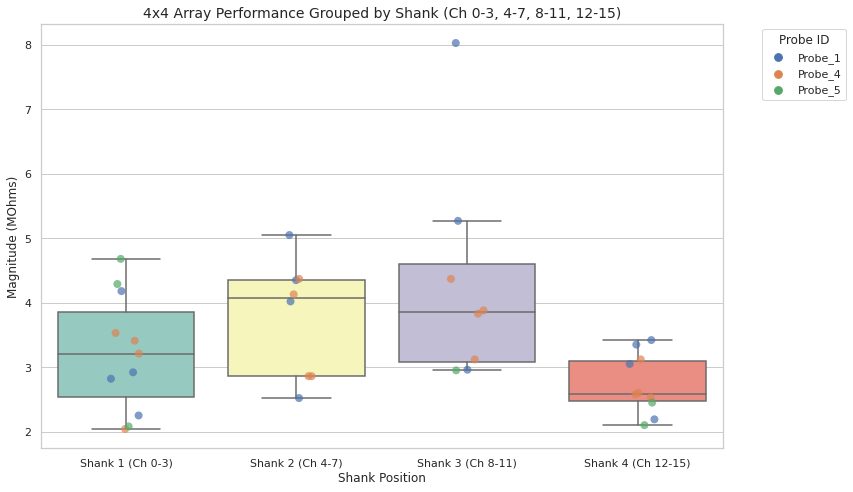

In [117]:
# Create Plot 2: 4x4 Arrays only, grouped by Shank

df_4x4 = df[df['Array_Shape'] == '4x4'].copy()
df_4x4_filt = df_4x4[df_4x4['Mag_MOhms'] < 10]

plt.figure(figsize=(12, 7))
sns.boxplot(data=df_4x4_filt, x='Shank', y='Mag_MOhms', palette='Set3', showfliers=False)
sns.stripplot(data=df_4x4_filt, x='Shank', y='Mag_MOhms', hue='Probe_ID', palette='deep', alpha=0.7, jitter=True, s=8)
# plt.yscale('log')
plt.title('4x4 Array Performance Grouped by Shank (Ch 0-3, 4-7, 8-11, 12-15)', fontsize=14)
plt.ylabel('Magnitude (MOhms)', fontsize=12)
plt.xlabel('Shank Position', fontsize=12)
plt.legend(title='Probe ID', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig('4x4_shank_<10MOhms_analysis.png')

# Statistical Summary for Shanks in 4x4
shank_stats = df_4x4.groupby('Shank')['Mag_MOhms'].agg(['mean', 'std', 'median', 'count']).reset_index()
print("Shank Statistics for 4x4 Arrays:")
print(shank_stats)

In [54]:
def plot_single_probe(probe_id):
    # 2. Filter data for the specific probe and sort by channel
    probe_df = df[df['Probe_ID'] == probe_id].sort_values('Probe_Chan')
    probe_df['Status'] = probe_df['Mag_MOhms'].apply(lambda x: 'High Z (>10.0 MOhms)' if x > 10.0 else 'Good')
    color_map = {'Good': '#2ecc71', 'High Z (>10.0 MOhms)': '#e74c3c'}
    
    if probe_df.empty:
        print(f"No data found for {probe_id}")
        return

    # 3. Set up the plotting environment
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8), sharex=True)
    sns.set_theme(style="whitegrid")

    # --- Plot 1: Magnitude ---
    # sns.barplot(data=probe_df, x='Probe_Chan', y='Mag_MOhms', ax=ax1, palette='viridis')
    sns.barplot(data=probe_df, x='Probe_Chan', y='Mag_MOhms', hue='Status', palette=color_map, ax=ax1, dodge=False)
    ax1.set_title(f'Impedance Magnitude for {probe_id} (@ 1kHz)', fontsize=14)
    ax1.set_ylabel('Magnitude (MOhms)', fontsize=12)
    
    # Add a horizontal line for the theoretical 30um target (0.286 MOhms)
    ax1.axhline(0.286, color='red', linestyle='--', label='Theoretical Target (0.286MOhms)')
    ax1.legend()

    # --- Plot 2: Phase ---
    sns.barplot(data=probe_df, x='Probe_Chan', y='Phase_deg', ax=ax2, palette='magma')
    ax2.set_title(f'Impedance Phase for {probe_id} (@ 1kHz)', fontsize=14)
    ax2.set_ylabel('Phase (Degrees)', fontsize=12)
    ax2.set_xlabel('Probe Channel', fontsize=12)
    ax2.set_ylim(-110, 0) # Phase is usually negative

    plt.tight_layout()
    # plt.savefig(f'{probe_id}_impedance_profile.png')
    plt.show()

# Usage:
# plot_single_probe('all_probes_03102026.csv', 'Probe_1')

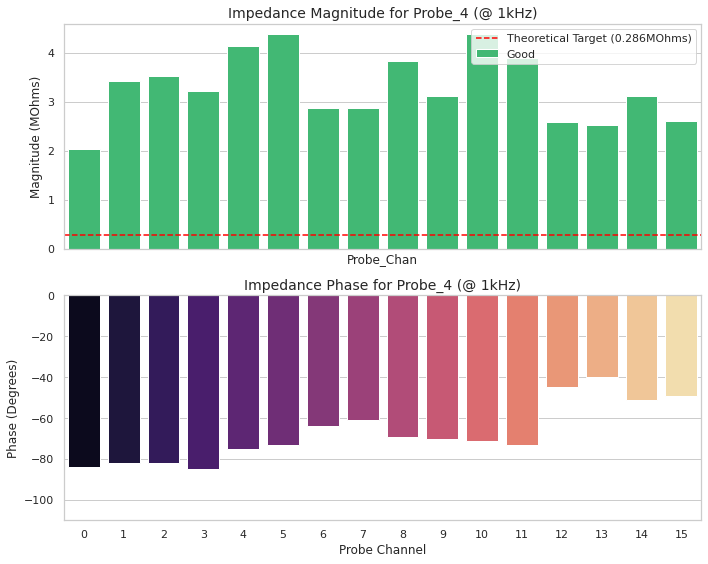

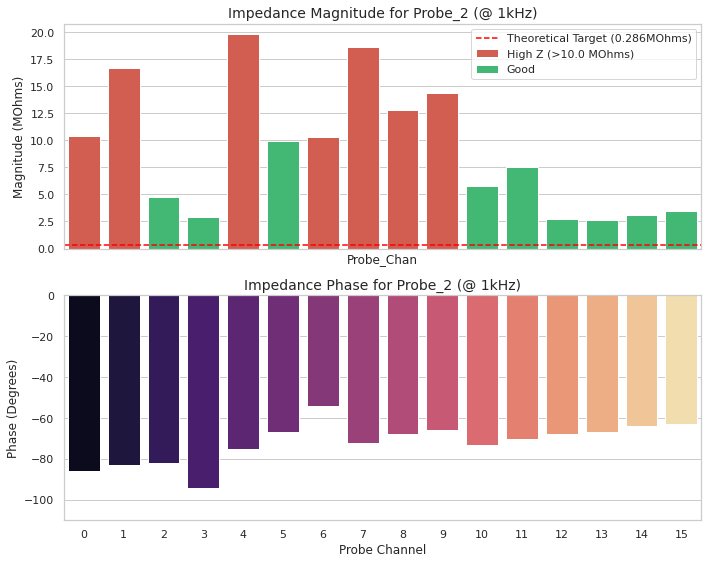

In [112]:
prb = "Probe_4"
plot_single_probe(prb)

prb = "Probe_2"
plot_single_probe(prb)

In [106]:
def plot_probe_grid_fixed(df, save_fig_name=""):
    # Group probes by shape
    probes_1x16 = sorted(df[df['Array_Shape'] == '1x16']['Probe_ID'].unique())[:3]
    probes_4x4 = sorted(df[df['Array_Shape'] == '4x4']['Probe_ID'].unique())[:3]
    
    fig, axes = plt.subplots(2, 3, figsize=(18, 10), sharey=True)
    sns.set_theme(style="whitegrid")
    
    # Define colors
    color_map = {'Good': '#2ecc71', 'High Z': '#e74c3c'}
    
    # Helper for row plotting
    def plot_row(probe_list, row_idx, title_prefix, is_4x4=False):
        for i, probe_id in enumerate(probe_list):
            ax = axes[row_idx, i]
            data = df[df['Probe_ID'] == probe_id].sort_values('Probe_Chan').copy()
            data['Status'] = data['Mag_MOhms'].apply(lambda x: 'High Z' if x >= 10.0 else 'Good')
            trace_w = data['Trace_Width_um'].iloc[0]
            tip_geom = data['Tip_Geometry'].iloc[0]
            
            # Use barplot without the legend parameter inside barplot to avoid version issues
            sns.barplot(data=data, x='Probe_Chan', y='Mag_MOhms', hue='Status', 
                        palette=color_map, ax=ax, dodge=False)
            
            # Cleanup Legend
            if i == 2 and row_idx == 0:
                ax.legend(title='Status', loc='upper right')
            else:
                if ax.get_legend() is not None:
                    ax.get_legend().remove()
            
            # Styling
            # ax.set_title(f'{title_prefix}: {probe_id}', fontsize=14, fontweight='bold')
            ax.set_title(f'{title_prefix}: {probe_id}\n({trace_w}µm width, {tip_geom} tip)',fontsize=12, fontweight='bold')
            ax.set_ylabel('Magnitude (MOhms)' if i == 0 else '')
            ax.set_xlabel('Channel Index')
            # ax.set_yscale('log')
            ax.set_ylim([0, 30])
            ax.axhline(0.286, color='blue', linestyle='--', alpha=0.6, label='Theoretical Target')
            
            # Special markers for 4x4
            if is_4x4:
                for boundary in [3.5, 7.5, 11.5]:
                    ax.axvline(boundary, color='#34495e', linestyle='--', alpha=0.8, linewidth=2)

    plot_row(probes_1x16, 0, '1x16 Array')
    plot_row(probes_4x4, 1, '4x4 Array', is_4x4=True)

    plt.suptitle('Comparison of Electrode Impedance Across 6 Probes (Good vs. High Z)', fontsize=20, y=0.98)
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    if save_fig_name != "":
        plt.savefig(save_fig_name)
        # plt.savefig('electrode_grid_summary.png')
    print("Grid plot saved as electrode_grid_summary_v2.png")

Grid plot saved as electrode_grid_summary_v2.png


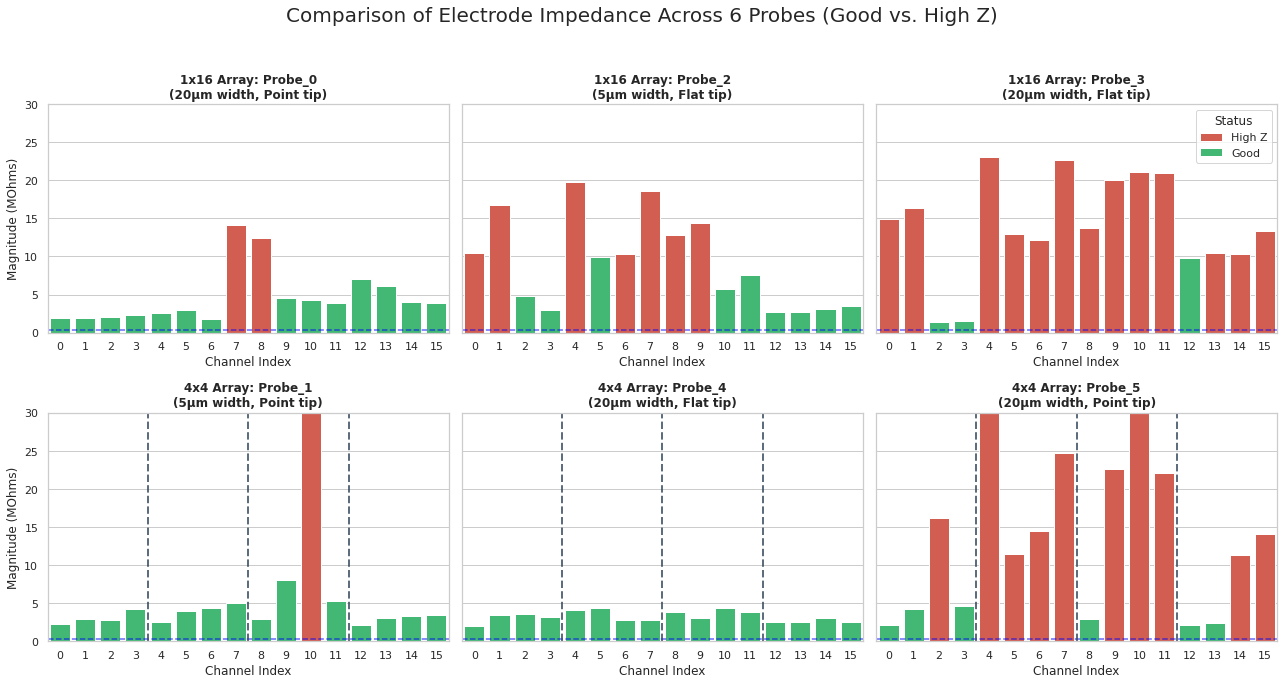

In [107]:
## All Electrode Channels

df = pd.read_csv('all_probes_03102026.csv')

# plot_probe_grid_fixed(df,save_fig_name="electrode_grid_df_cleaned_03102026.png")
plot_probe_grid_fixed(df)

Grid plot saved as electrode_grid_summary_v2.png


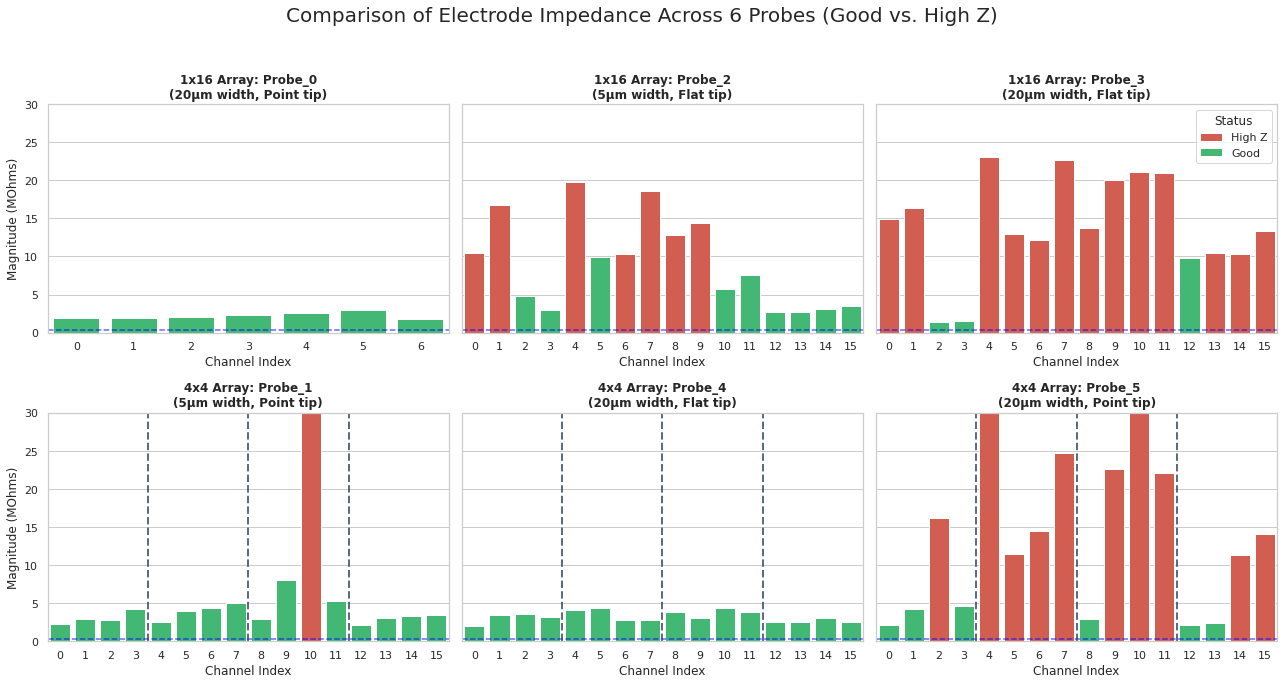

In [110]:
df_cleaned = pd.read_csv("cleaned_probes_03102026.csv") # Removing Electrodes 7-15 from Probe_0

# plot_probe_grid_fixed(df_cleaned,save_fig_name="electrode_grid_df_cleaned_03102026.png")
plot_probe_grid_fixed(df_cleaned)

In [99]:
def get_comprehensive_stats(df):
    """
    Calculates overall and 'good' channel statistics, plus yield,
    across different design parameters in the probe dataset.
    """
    results = {}
    # List of categories we want to analyze
    categories = ['Probe_ID', 'Tip_Geometry', 'Trace_Width_um', 'Array_Shape']
    
    for cat in categories:
        if cat not in df.columns:
            continue
            
        # 1. Calculate stats for ALL channels
        all_stats = df.groupby(cat)['Mag_MOhms'].agg(['mean', 'std', 'count']).rename(
            columns={'mean': 'Avg (All)', 'std': 'Std (All)', 'count': 'N_Total'}
        )
        
        # 2. Calculate stats for GOOD channels (< 10 MOhms)
        good_df = df[df['Mag_MOhms'] < 10.0]
        good_stats = good_df.groupby(cat)['Mag_MOhms'].agg(['mean', 'std', 'count']).rename(
            columns={'mean': 'Avg (Good)', 'std': 'Std (Good)', 'count': 'N_Good'}
        )
        
        # 3. Merge 'All' and 'Good' stats together
        summary = pd.concat([all_stats, good_stats], axis=1).fillna(0)
        
        # 4. Calculate Yield Percentage
        summary['Yield (%)'] = (summary['N_Good'] / summary['N_Total']) * 100
        
        # 5. Organize columns for easy reading
        column_order = ['N_Total', 'Avg (All)', 'Std (All)', 'N_Good', 'Avg (Good)', 'Std (Good)', 'Yield (%)']
        results[cat] = summary[column_order]
        
    # Overall Results
    
    # Filter for good channels
    good_df = df[df['Mag_MOhms'] < 10.0]
    summary = pd.DataFrame({
        'Total Electrodes': [len(df)],
        'Avg Impedance (All)': [df['Mag_MOhms'].mean()],
        'Std Dev (All)': [df['Mag_MOhms'].std()],
        'Functional Electrodes': [len(good_df)],
        'Avg Impedance (Good)': [good_df['Mag_MOhms'].mean()],
        'Std Dev (Good)': [good_df['Mag_MOhms'].std()],
        'Overall Yield (%)': [(len(good_df) / len(df)) * 100]
    })
    
    results["Overall"] = summary

    return results

# --- HOW TO CALL IT ---
# df = pd.read_csv('cleaned_probes_03102026.csv')
# all_summaries = get_comprehensive_stats(df)

# # To view a specific table, e.g., Trace Width:
# print(all_summaries['Trace_Width_um'])

In [100]:
df_cleaned = pd.read_csv('cleaned_probes_03102026.csv')
stat_results = get_comprehensive_stats(df_cleaned)

In [101]:
stat_results.keys()

dict_keys(['Probe_ID', 'Tip_Geometry', 'Trace_Width_um', 'Array_Shape', 'Overall'])

In [103]:
stat_results["Overall"]

,Total Electrodes,Avg Impedance (All),Std Dev (All),Functional Electrodes,Avg Impedance (Good),Std Dev (Good),Overall Yield (%)
0,87,9.102414,10.607481,56,3.548393,1.794613,64.367816


In [102]:
stat_results["Probe_ID"]

,N_Total,Avg (All),Std (All),N_Good,Avg (Good),Std (Good),Yield (%)
Probe_ID,,,,,,,
Probe_0,7,2.231429,0.433529,7,2.231429,0.433529,100.00
Probe_1,16,8.442500,18.792303,15,3.758667,1.513482,93.75
Probe_2,16,9.126250,5.931866,9,4.780000,2.560395,56.25
Probe_3,16,14.056250,6.659219,3,4.233333,4.873667,18.75
Probe_4,16,3.277500,0.697706,16,3.277500,0.697706,100.00
Probe_5,16,13.615625,10.260130,6,3.091667,1.131148,37.50


In [96]:
stat_results["Tip_Geometry"]

,N_Total,Avg (All),Std (All),N_Good,Avg (Good),Std (Good),Yield (%)
Tip_Geometry,,,,,,,
Flat,48,8.82,6.735091,28,3.862857,2.11447,58.333333
Point,39,9.45,14.082534,28,3.233929,1.37276,71.794872


In [97]:
stat_results["Trace_Width_um"]

,N_Total,Avg (All),Std (All),N_Good,Avg (Good),Std (Good),Yield (%)
Trace_Width_um,,,,,,,
5,32,8.784375,13.712256,24,4.141667,1.982328,75.000000
20,55,9.287455,8.435681,32,3.103438,1.523692,58.181818


In [98]:
stat_results["Array_Shape"]

,N_Total,Avg (All),Std (All),N_Good,Avg (Good),Std (Good),Yield (%)
Array_Shape,,,,,,,
1x16,39,9.911282,7.055653,19,3.754737,2.661128,48.717949
4x4,48,8.445208,12.831668,37,3.442432,1.160001,77.083333


In [ ]:
# print("Overall yield: ", probe_summary["n_good"].sum()/96*100, "%")